# 00. 선형대수 기초 (Linear Algebra Foundations)

이번 단원에서는 딥러닝에 필요한 **선형대수 기초**를 배워보겠습니다.

## 학습 목표
- 벡터와 행렬의 기하학적 의미
- 내적(Dot Product)과 행렬곱의 직관
- 선형 변환과 차원 변환의 이해
- 신경망 수학의 기초

## 왜 이 단원이 필요한가?

딥러닝의 모든 연산은 **행렬 연산**입니다. 신경망을 이해하려면 선형대수의 직관이 필수입니다.

**궁금증**: 신경망이 숫자를 어떻게 처리할까?
- **답**: 모든 데이터를 숫자 배열(벡터/행렬)로 표현하고 행렬 연산으로 변환

**예시**:
- 이미지 = 픽셀 행렬
- 텍스트 = 단어 벡터
- 주식 가격 = 시계열 벡터

**이 단원을 이해하면**:
- 텐서가 왜 필요한지 알 수 있음
- 행렬곱이 신경망의 핵심인 이유를 알 수 있음
- 이후 PyTorch 학습이 쉬워짐

**중요**: 여기서는 PyTorch를 몰라도 됩니다. 순수 수학 개념만 배웁니다!

## 이 단원을 배우기 전에

**고등학교 수학 복습**: 벡터와 행렬의 기본 연산을 기억하시나요?

## 이 단원 다음에는

**다음 단원 (00a)**: 선형대수를 이해했으니, 이제 미적분 기초 (Calculus Foundations)를 배워봅시다.

---
# 1. 직관적 이해 (Why)
---

## 1.1 왜 선형대수가 필요한가?

### 딥러닝 = 행렬 연산

신경망의 모든 계산은 행렬 곱셈입니다!

**예시**: 이미지 분류
- 입력: 28×28 = 784개의 픽셀 (벡터)
- 가중치: 784×10 행렬
- 출력: 10개의 클래스 점수 (벡터)

**계산**: 벡터 × 행렬 = 벡터 (행렬 곱셈!)

### 기하학적 직관

- **벡터**: 데이터의 한 샘플 (숫자들의 배열)
- **행렬**: 변환 규칙 (공간을 바꾸는 함수)
- **행렬곱**: 데이터를 새로운 공간으로 투영
- **내적**: 두 벡터의 유사도 측정

**의미**: 신경망은 데이터를 "더 잘 분리되는 공간"으로 변환하는 행렬을 학습합니다!

### 이후 연결

나중에 PyTorch를 배우면, 이 행렬 곱셈이 바로 `nn.Linear` 레이어입니다!


---
# 2. 수학적 기초 (What)
---

## 2.1 벡터의 기하학적 의미

벡터는 **방향과 크기**를 가진 화살표입니다.

2차원 벡터: $\vec{v} = \begin{bmatrix} v_1 \\ v_2 \end{bmatrix}$

**기하학적 해석**:
- **크기**: $\|\vec{v}\| = \sqrt{v_1^2 + v_2^2}$
- **방향**: 원점에서 $(v_1, v_2)$로 가는 화살표

### 머신러닝에서의 의미

**입력 데이터**: 이미지, 텍스트, 사용자 특성 → 모두 벡터  
**가중치 벡터**: 각 뉴런이 학습하는 "패턴"


/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/3529988968.py:33: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
 

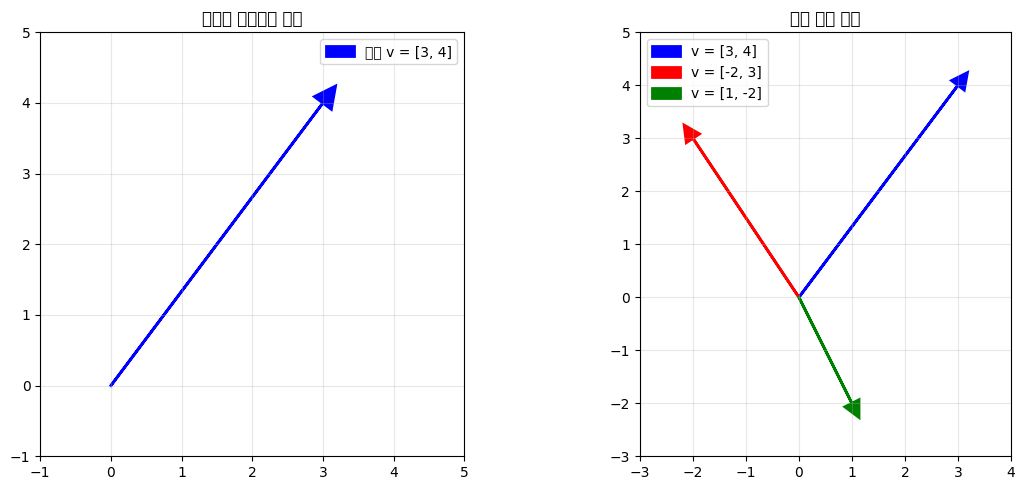

벡터의 성질:
- 벡터 [3 4]: 크기 = 5.00
- 벡터 [-2  3]: 크기 = 3.61
- 벡터 [ 1 -2]: 크기 = 2.24
→ 머신러닝: 각 데이터 샘플이 하나의 벡터


In [1]:
# 벡터 시각화
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) 기본 벡터
ax1 = axes[0]
v = np.array([3, 4])
ax1.arrow(0, 0, v[0], v[1], head_width=0.3, head_length=0.3,
          fc='blue', ec='blue', linewidth=2, label='벡터 v = [3, 4]')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 5)
ax1.set_aspect('equal')
ax1.legend()
ax1.set_title('벡터의 기하학적 표현')

# 2) 여러 벡터 비교
ax2 = axes[1]
vectors = [np.array([3, 4]), np.array([-2, 3]), np.array([1, -2])]
colors = ['blue', 'red', 'green']
for v, color in zip(vectors, colors):
    ax2.arrow(0, 0, v[0], v[1], head_width=0.3, head_length=0.3,
              fc=color, ec=color, linewidth=2, label=f'v = [{v[0]}, {v[1]}]')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-3, 4)
ax2.set_ylim(-3, 5)
ax2.set_aspect('equal')
ax2.legend()
ax2.set_title('여러 벡터 비교')

plt.tight_layout()
plt.show()

print("벡터의 성질:")
for v in vectors:
    print(f"- 벡터 {v}: 크기 = {np.linalg.norm(v):.2f}")
print("→ 머신러닝: 각 데이터 샘플이 하나의 벡터")


## 2.2 내적(Dot Product)의 의미

두 벡터의 내적:

$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2 = \|\vec{a}\| \|\vec{b}\| \cos(\theta)$$

**기하학적 의미**: 두 벡터의 **정렬도(alignment)** 측정
- 같은 방향 → 내적 최대
- 수직 → 내적 = 0
- 반대 방향 → 내적 최소

### 머신러닝 연결

**내적 = 유사도**: 두 벡터가 얼마나 비슷한 패턴인가?

**예시**: 고양이 이미지 인식
- 입력 벡터: 픽셀들의 배열
- 가중치 벡터: "고양이 패턴"
- 내적이 크다 → 이미지가 고양이와 유사!


## 2.2a 내적 공식이 나오게 된 이유

내적 공식의 두 가지 표현이 같은 이유:

$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2 = \|\vec{a}\| \|\vec{b}\| \cos(\theta)$$

### 코사인 법칙으로 유도

**1단계**: 코사인 법칙 적용

두 벡터의 차에 대해:
$$|\vec{a} - \vec{b}|^2 = |\vec{a}|^2 + |\vec{b}|^2 - 2|\vec{a}||\vec{b}|\cos(\theta)$$

**2단계**: 좌표로 전개

$$|\vec{a} - \vec{b}|^2 = (a_1 - b_1)^2 + (a_2 - b_2)^2$$
$$= a_1^2 + a_2^2 + b_1^2 + b_2^2 - 2(a_1b_1 + a_2b_2)$$
$$= |\vec{a}|^2 + |\vec{b}|^2 - 2(a_1b_1 + a_2b_2)$$

**3단계**: 양식 비교

2단계 결과를 1단계 공식과 비교:
$$|\vec{a}|^2 + |\vec{b}|^2 - 2(a_1b_1 + a_2b_2) = |\vec{a}|^2 + |\vec{b}|^2 - 2|\vec{a}||\vec{b}|\cos(\theta)$$

따라서:
$$a_1b_1 + a_2b_2 = |\vec{a}||\vec{b}|\cos(\theta)$$

### 의미

내적은 **좌표와 무관한 기하학적 의미**를 가집니다.
- 좌표를 바꿔도 값이 같음 (회전 불변성)
- 길이와 각도만 알면 계산 가능
- 머신러닝에서 유용: 데이터 변환에 안정적



/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/2425112657.py:31: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu S

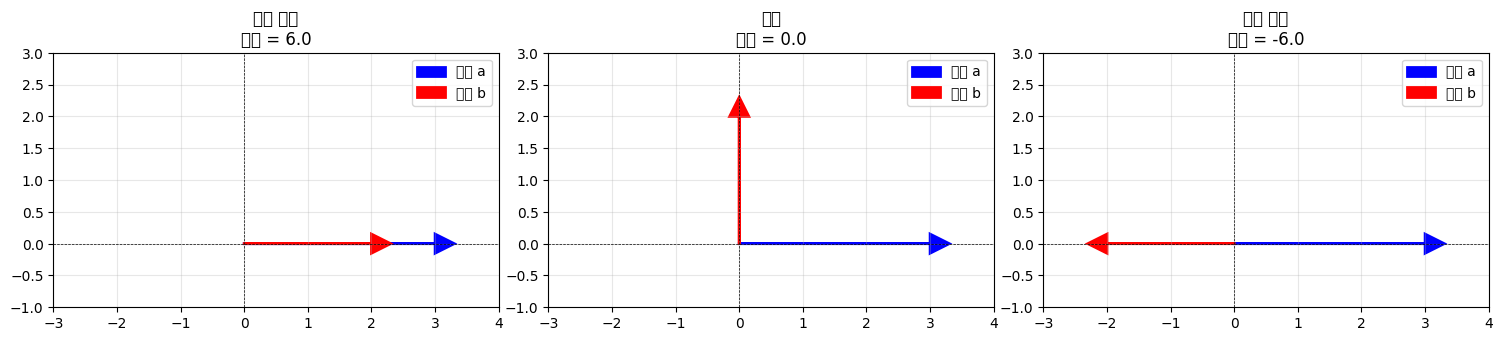

내적의 의미:
- 같은 방향: 내적 큼 → 유사한 패턴
- 수직: 내적 0 → 무관한 패턴
- 반대 방향: 내적 음수 → 반대 패턴
→ 가중치 벡터와 입력의 내적이 크면 해당 뉴런 활성화!


In [3]:
# 내적의 기하학적 의미 시각화
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

a = np.array([3, 0])
vectors_b = [
    (np.array([2, 0]), "같은 방향"),
    (np.array([0, 2]), "수직"),
    (np.array([-2, 0]), "반대 방향")
]

for i, (b, title) in enumerate(vectors_b):
    ax = axes[i]
    ax.arrow(0, 0, a[0], a[1], head_width=0.3, head_length=0.3,
             fc='blue', ec='blue', linewidth=2, label='벡터 a')
    ax.arrow(0, 0, b[0], b[1], head_width=0.3, head_length=0.3,
             fc='red', ec='red', linewidth=2, label='벡터 b')
    
    dot = np.dot(a, b)
    ax.set_title(f'{title}\n내적 = {dot:.1f}')
    ax.set_xlim(-3, 4)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print("내적의 의미:")
print("- 같은 방향: 내적 큼 → 유사한 패턴")
print("- 수직: 내적 0 → 무관한 패턴")
print("- 반대 방향: 내적 음수 → 반대 패턴")
print("→ 가중치 벡터와 입력의 내적이 크면 해당 뉴런 활성화!")


### 2.2b 왜 내적이 유사도인가?

**핵심 질문**: 왜 내적이 "유사도"로 작동하는가?

내적 공식:
$$\vec{a} \cdot \vec{b} = |\vec{a}||\vec{b}|\cos(\theta)$$

**직관적 해석**:
1. **같은 방향** ($\theta = 0°$): $\cos(0°) = 1$ → 내적 최대
2. **수직** ($\theta = 90°$): $\cos(90°) = 0$ → 내적 0
3. **반대 방향** ($\theta = 180°$): $\cos(180°) = -1$ → 내적 최소

→ **각도가 작을수록(유사할수록) 내적이 큼**

**정규화된 내적 (코사인 유사도)**:
$$\text{cosine similarity} = \frac{\vec{a} \cdot \vec{b}}{|\vec{a}||\vec{b}|} = \cos(\theta)$$

이것은 **-1에서 1 사이의 유사도 점수**:
- 1: 완전히 유사
- 0: 무관
- -1: 완전히 반대

### 내적을 사용하는 이유

**1. 수학적으로 자연스러움**: 각도가 작을수록 내적이 큼

**2. 계산 효율성**: 단순히 좌표 곱셈 합산
- $\vec{a} \cdot \vec{b} = a_1b_1 + a_2b_2 + \cdots + a_nb_n$

**3. 기하학적 의미**: 임의 좌표계에서도 동일

**4. 선형성**: 다음이 성립
- $(\vec{a} + \vec{b}) \cdot \vec{c} = \vec{a} \cdot \vec{c} + \vec{b} \cdot \vec{c}$

**⚠️ 주의**: 순수 내적은 **벡터의 크기에 영향**을 받습니다!

예시: $(1,2) \cdot (1,2) = 5$ vs $(1,2) \cdot (2,4) = 10$

후자가 더 큰데, 실제로는 $(2,4) = 2 \times (1,2)$ → **같은 방향**이므로 더 유사합니다!

→ **순수 유사도를 측정하려면 정규화 필수** (코사인 유사도 사용)

**머신러닝 예시**: 고양이 이미지 분류
- 가중치 벡터: "고양이 패턴" (학습으로 찾은 특징)
- 입력 벡터: 새 이미지 픽셀들
- **정규화된 내적이 크다** = 이미지가 고양이 패턴과 비슷 = 모델이 "고양이"라고 판단


In [ ]:
# 크기 vs 정규화 유사도 비교
import numpy as np

print("=== 순수 내적 vs 정규화된 내적(코사인 유사도) ===\n")

v1 = np.array([1, 2])
v2 = np.array([1, 2])  # 동일
v3 = np.array([2, 4])  # v1의 2배 (같은 방향)

print("벡터 비교:")
print(f"v1 = {v1}")
print(f"v2 = {v2} (v1과 동일)")
print(f"v3 = {v3} (v1의 2배, 같은 방향)\n")

# 순수 내적
dot12 = np.dot(v1, v2)
dot13 = np.dot(v1, v3)

print("순수 내적 (크기에 영향받음):")
print(f"v1 · v2 = {dot12}")
print(f"v1 · v3 = {dot13}")
print(f"→ v3이 더 크지만, 실제로는 v2가 더 유사! ❌\n")

# 코사인 유사도 (정규화된 내적)
cos_sim12 = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
cos_sim13 = np.dot(v1, v3) / (np.linalg.norm(v1) * np.linalg.norm(v3))

print("코사인 유사도 (방향만 측정):")
print(f"cos(v1, v2) = {cos_sim12:.3f}")
print(f"cos(v1, v3) = {cos_sim13:.3f}")
print(f"→ 둘 다 1.0으로 완전히 유사! ✓\n")

print("결론:")
print("- 순수 내적: 크기와 각도 모두 고려")
print("- 코사인 유사도: 각도만 고려 (유사도 측정에 적합)")
print("- 머신러닝: 일반적으로 코사인 유사도 또는 정규화된 벡터 사용")


/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_112983/910493625.py:45: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_

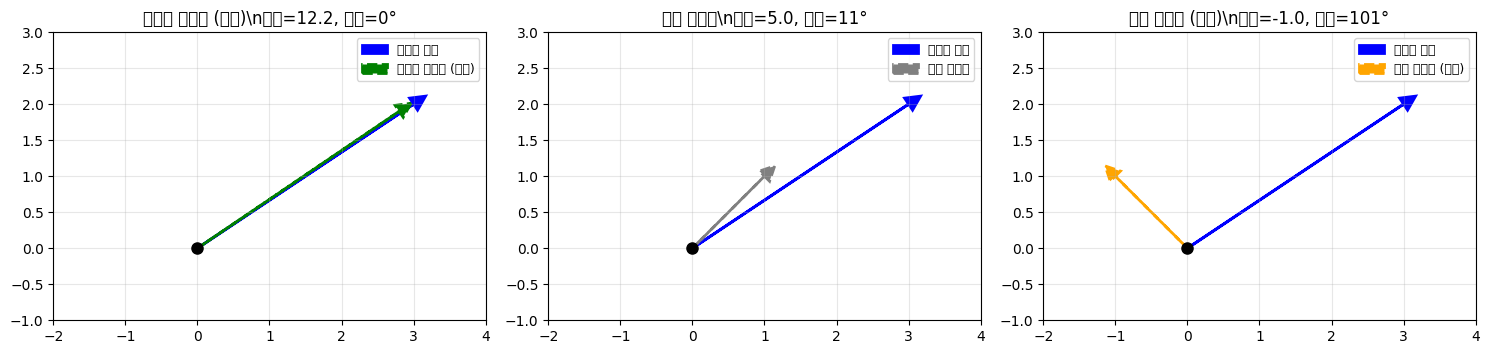

핵심 통찰:
→ 내적이 큼 = 각도 작음 = 패턴 유사
→ 신경망은 내적이 큰 패턴에 '행동'(활성화)


In [2]:
# 내적과 유사도의 관계 시각화
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 기준 벡터 (고양이 패턴)
cat_pattern = np.array([3, 2])

# 다양한 입력 이미지
images = [
    (np.array([2.8, 1.9]), "고양이 이미지 (유사)", "green"),
    (np.array([1, 1]), "일반 이미지", "gray"),
    (np.array([-1, 1]), "다른 이미지 (무관)", "orange"),
]

for i, (img_vec, label, color) in enumerate(images):
    ax = axes[i]
    
    # 기준 패턴
    ax.arrow(0, 0, cat_pattern[0], cat_pattern[1], 
             head_width=0.2, head_length=0.2,
             fc='blue', ec='blue', linewidth=2, label='고양이 패턴')
    
    # 입력 이미지
    ax.arrow(0, 0, img_vec[0], img_vec[1], 
             head_width=0.2, head_length=0.2,
             fc=color, ec=color, linewidth=2, label=label, linestyle='--')
    
    # 내적 계산
    dot = np.dot(cat_pattern, img_vec)
    cosine_sim = dot / (np.linalg.norm(cat_pattern) * np.linalg.norm(img_vec))
    angle = np.arccos(np.clip(cosine_sim, -1, 1)) * 180 / np.pi
    
    # 각도 시각화
    ax.plot([0], [0], 'ko', markersize=8)
    
    ax.set_title(f'{label}\\n내적={dot:.1f}, 각도={angle:.0f}°')
    ax.set_xlim(-2, 4)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("핵심 통찰:")
print("→ 내적이 큼 = 각도 작음 = 패턴 유사")
print("→ 신경망은 내적이 큰 패턴에 '행동'(활성화)")


## 2.3 행렬의 기하학적 의미

행렬은 **공간을 변환**하는 함수입니다.

행렬곱: $A\vec{x} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$

**열벡터 관점**: 행렬의 열벡터들의 선형결합

$$A\vec{x} = x_1 \begin{bmatrix} a_{11} \\ a_{21} \end{bmatrix} + x_2 \begin{bmatrix} a_{12} \\ a_{22} \end{bmatrix}$$

**주의**: 선형결합에서는 순서가 중요!
- $x_1a_1 + x_2a_2 \neq x_2a_1 + x_1a_2$ (일반적으로)
- 계수와 열벡터가 1:1 대응되어야 함

**내적 관점**: 각 출력 성분은 행벡터와 입력 벡터의 내적

$$(A\vec{x})_i = \sum_{j=1}^{n} a_{ij} x_j = \vec{a}_i \cdot \vec{x}$$

여기서 $\vec{a}_i$는 행렬 $A$의 $i$번째 행벡터입니다.

**시그마 표기**: 
- $\sum_{j=1}^{n} a_{ij} x_j = a_{i1}x_1 + a_{i2}x_2 + \cdots + a_{in}x_n$
- 이는 각 행벡터와 입력 벡터의 내적을 나타냅니다

### ⚠️ 벡터와 행렬의 교환법칙 차이

**벡터 내적**: 교환법칙 성립
- $\vec{a} \cdot \vec{b} = \vec{b} \cdot \vec{a}$ ✓
- 원인: 스칼라(숫자)

**행렬 곱셈**: 교환법칙 불성립
- $AB \neq BA$ (일반적으로) ✗
- 원인: 순서가 다른 변환

**왜?**: 
- $AB$: 먼저 $B$ 적용, 그 다음 $A$ 적용
- $BA$: 먼저 $A$ 적용, 그 다음 $B$ 적용
- 적용 순서가 다르면 결과가 다름!

### 머신러닝 연결

**행렬 곱셈 = 공간 변환**

각 출력 = 가중치 벡터와 입력의 내적

**의미**: 입력을 새로운 공간으로 투영하는 변환

**예시**: 10차원 입력을 5차원으로 변환
- 10×5 행렬로 곱하면 5차원 출력
- 각 출력은 "특정 패턴을 얼마나 가지고 있는가"


In [ ]:
# 열벡터 관점에서 순서의 중요성
import numpy as np

print("=== 열벡터 선형결합: 순서 중요 ===\n")

A = np.array([[1, 2], [3, 4]])
x = np.array([5, 6])

print(f"A = \n{A}")
print(f"x = {x}\n")

# 열벡터 추출
a1 = A[:, 0]  # 첫 번째 열
a2 = A[:, 1]  # 두 번째 열

print("열벡터 관점:")
print(f"a₁ = {a1}")
print(f"a₂ = {a2}\n")

# Ax = x₁a₁ + x₂a₂
result1 = x[0] * a1 + x[1] * a2
print(f"Ax = x₁a₁ + x₂a₂ = {x[0]}×{a1} + {x[1]}×{a2}")
print(f"    = {result1}\n")

# 순서 바꾸면?
result2 = x[1] * a1 + x[0] * a2
print(f"x₂a₁ + x₁a₂ = {x[1]}×{a1} + {x[0]}×{a2}")
print(f"    = {result2}\n")

# 실제 행렬곱
Ax_correct = A @ x
print(f"실제 A·x = {Ax_correct}\n")

print(f"→ x₁a₁ + x₂a₂ = A·x? {np.allclose(result1, Ax_correct)} ✓")
print(f"→ x₂a₁ + x₁a₂ = A·x? {np.allclose(result2, Ax_correct)} ✗")
print("→ 순서가 중요함!")


In [ ]:
# 벡터 내적과 행렬 곱셈의 교환법칙 비교
import numpy as np

print("=== 벡터 내적 vs 행렬 곱셈 교환법칙 ===\n")

# 벡터 내적
a = np.array([1, 2])
b = np.array([3, 4])
print("벡터:")
print(f"a = {a}")
print(f"b = {b}\n")

print("벡터 내적:")
dot_ab = np.dot(a, b)
dot_ba = np.dot(b, a)
print(f"a · b = {dot_ab}")
print(f"b · a = {dot_ba}")
print(f"→ a · b = b · a? {dot_ab == dot_ba} ✓ (교환법칙 성립!)\n")

# 행렬 곱셈
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("행렬:")
print(f"A = \n{A}")
print(f"\nB = \n{B}\n")

print("행렬 곱셈:")
AB = A @ B
BA = B @ A
print(f"A @ B = \n{AB}")
print(f"\nB @ A = \n{BA}")
print(f"→ A @ B = B @ A? {np.allclose(AB, BA)} ✗ (교환법칙 불성립!)\n")

print("이유:")
print("- 벡터 내적: 스칼라 (순서 무관)")
print("- 행렬 곱셈: 순서에 따라 다른 변환 결과")


---
# 3. 이후 PyTorch에서 보면
---

## 3.1 텐서란?

**이미 배운 개념을 다른 이름으로 부르는 것입니다!**

PyTorch는 벡터와 행렬을 **텐서(tensor)**라는 이름으로 부릅니다:

- **스칼라**: 0차원 텐서 (하나의 숫자)
- **벡터**: 1차원 텐서 (숫자의 배열)
- **행렬**: 2차원 텐서 (벡터의 배열)
- **텐서**: 3차원 이상 (행렬의 배열의 배열...)

**중요**: 텐서는 새로운 개념이 아니라, 벡터와 행렬을 "다차원 배열"이라는 이름으로 일반화한 것입니다!


In [4]:
# numpy로 벡터와 행렬 표현
from typing import Any
import numpy as np
from numpy._typing import NDArray

print("=== 차원별 배열 ===\n")

# 스칼라 (0차원)
scalar: NDArray[Any] = np.array(3.14)
print(f"스칼라: {scalar}, shape: {scalar.shape}, 차원: {scalar.ndim}D")

# 벡터 (1차원)
vector = np.array([1, 2, 3])
print(f"벡터: {vector}, shape: {vector.shape}, 차원: {vector.ndim}D")

# 행렬 (2차원)
matrix = np.array([[1, 2, 3], [4, 5, 6]])
print(f"행렬:\n{matrix}")
print(f"shape: {matrix.shape}, 차원: {matrix.ndim}D")

# 3차원 배열
array_3d = np.random.randn(2, 3, 4)
print(f"\n3D 배열 shape: {array_3d.shape}, 차원: {array_3d.ndim}D")
print("→ 2개의 행렬, 각 3×4 크기\n")

print("머신러닝 의미:")
print("- 이미지: (배치, 채널, 높이, 너비) → 4차원")
print("- 모든 데이터는 숫자 배열로 표현!")
print("\n참고: 나중에 PyTorch에서 이 배열을 '텐서'라고 부릅니다!")


=== 차원별 배열 ===

스칼라: 3.14, shape: (), 차원: 0D
벡터: [1 2 3], shape: (3,), 차원: 1D
행렬:
[[1 2 3]
 [4 5 6]]
shape: (2, 3), 차원: 2D

3D 배열 shape: (2, 3, 4), 차원: 3D
→ 2개의 행렬, 각 3×4 크기

머신러닝 의미:
- 이미지: (배치, 채널, 높이, 너비) → 4차원
- 모든 데이터는 숫자 배열로 표현!

참고: 나중에 PyTorch에서 이 배열을 '텐서'라고 부릅니다!


## 3.2 신경망의 기본 연산

신경망의 가장 기본적인 계산은 **행렬곱 + 편향**입니다:

$$y = Wx + b$$

여기서:
- $x$: 입력 벡터
- $W$: 가중치 행렬 
- $b$: 편향 벡터
- $y$: 출력 벡터

**의미**: 
- 행렬 $W$가 입력 $x$를 새로운 공간으로 변환
- 편향 $b$가 기준점을 이동

**이후 연결**: 이 수식을 구현하는 것이 신경망 레이어입니다!


In [ ]:
# 행렬곱 + 편향 구현
import numpy as np

print("=== y = Wx + b 구현 ===\n")

np.random.seed(42)

# 입력 벡터 (4개 샘플, 각 5차원)
x = np.random.randn(4, 5)
print(f"입력 x shape: {x.shape}")

# 가중치 행렬 (3×5)
W = np.random.randn(3, 5)
print(f"가중치 W shape: {W.shape}")

# 편향 (3차원)
b = np.random.randn(3)
print(f"편향 b shape: {b.shape}\n")

# 행렬곱: W @ x.T (또는 x @ W.T)
y = x @ W.T + b
print(f"출력 y shape: {y.shape}")
print(f"\n출력 y:\n{y}\n")

print("핵심:")
print("- y = W @ x.T + b (행렬곱 + 편향)")
print("- 각 출력은 가중치 벡터와 입력의 내적!")
print("- 이것이 신경망 레이어의 기본 연산!")
print("\n참고: 나중에 PyTorch를 배우면 이걸 자동으로 해줍니다!")


---
# 4. 핵심 요약
---

## 이번 단원에서 배운 내용

### 1. 벡터와 행렬
- **벡터**: 방향과 크기를 가진 화살표 (데이터 샘플)
- **행렬**: 공간을 변환하는 함수 (선형 변환)
- **행렬곱**: 열벡터들의 선형결합으로 공간 변환
- **내적**: 두 벡터의 정렬도 측정 (유사도)

### 2. 머신러닝 연결
- **다차원 배열**: 벡터와 행렬을 일반화한 표현
- **기본 연산**: y = Wx + b (행렬곱 + 편향)
- **내적의 의미**: 두 벡터의 유사도 측정

### 3. 핵심 직관
- 모든 데이터는 숫자 배열(벡터/행렬)로 표현
- 행렬은 공간을 변환하는 함수
- 신경망은 데이터를 더 잘 분리되는 공간으로 변환

## 다음 단원 미리보기

**다음 단원 (00a)**: 미적분 기초 (Calculus Foundations)
- 선형대수로 구조를 이해했으니, 이제 **미적분** (Calculus)을 배웁니다
- **미분** (Derivative): 함수의 변화율 (기울기, slope)
- **기울기** (Gradient): 손실을 줄이는 방향
- **경사하강법** (Gradient Descent): 학습 알고리즘의 수학적 원리

**이후**: Python/PyTorch
- 미적분을 배운 후 Python으로 구현하는 방법을 배웁니다!

수학 기초가 탄탄해졌으니, 이제 구현을 배울 준비가 되었습니다!
